# 本章知识点总结：注意力分数（Attention Scoring Function）

> 承接上一章：注意力的统一写法是"对 value 加权平均"，但**权重到底怎么算**没说清楚。本章核心就是 **注意力分数函数 $a(\mathbf{q}, \mathbf{k})$**——它衡量 query 与 key 的匹配程度，分数经 softmax 归一化后就是注意力权重。本章介绍两种主流分数函数：**加性注意力** 和 **缩放点积注意力**。

---

## 1. 注意力机制的统一计算框架

设有一个查询 $\mathbf{q}$ 和 $m$ 个键值对 $(\mathbf{k}_1, \mathbf{v}_1), \dots, (\mathbf{k}_m, \mathbf{v}_m)$，注意力池化的输出为：

$$f(\mathbf{q}, (\mathbf{k}_1, \mathbf{v}_1), \dots, (\mathbf{k}_m, \mathbf{v}_m)) = \sum_{i=1}^{m} \alpha(\mathbf{q}, \mathbf{k}_i)\, \mathbf{v}_i$$

其中注意力权重由分数经 softmax 得到：

$$\alpha(\mathbf{q}, \mathbf{k}_i) = \mathrm{softmax}\big(a(\mathbf{q}, \mathbf{k}_i)\big) = \frac{\exp\big(a(\mathbf{q}, \mathbf{k}_i)\big)}{\sum_{j=1}^{m} \exp\big(a(\mathbf{q}, \mathbf{k}_j)\big)}$$

- **字符定义**：
  - $\mathbf{q}$：查询（query）向量
  - $\mathbf{k}_i$：第 $i$ 个键（key）向量
  - $\mathbf{v}_i$：第 $i$ 个值（value）向量
  - $a(\mathbf{q}, \mathbf{k}_i)$：**注意力分数函数**，输出一个标量，衡量 $\mathbf{q}$ 与 $\mathbf{k}_i$ 的相似/匹配程度
  - $\alpha(\mathbf{q}, \mathbf{k}_i)$：**注意力权重**，是分数经 softmax 归一化后的结果（非负、求和为 1）
- **公式描述**：先用分数函数 $a$ 给每个 key 与 query 的匹配度打分，再用 softmax 把这些分数变成一组和为 1 的权重，最后对 value 加权求和。**不同注意力机制的唯一区别，就是分数函数 $a$ 的设计。**

---

## 2. 掩码 softmax（Masked Softmax）

**动机**：实际中序列长度不一（如句子有填充 `<pad>`），有些 key 是无效的占位符，不应参与注意力计算。

**做法**：把超出**有效长度**的位置的分数设为一个**极大的负数（如 −1e6）**，这样 softmax 后这些位置的权重 ≈ 0。

- **公式描述**：$\exp(-10^6) \approx 0$，因此被遮蔽的位置在归一化后几乎不分配权重，等效于"看不见"这些无效 key。对应代码 `masked_softmax`：用 `valid_lens` 指定每行的有效长度，对其余位置填 `-1e6` 再做 softmax。

---

## 3. 加性注意力（Additive Attention）

**适用场景**：query 和 key 的**长度可以不同**（维度不一致）。

$$a(\mathbf{q}, \mathbf{k}) = \mathbf{w}_v^{\top} \tanh\big(\mathbf{W}_q \mathbf{q} + \mathbf{W}_k \mathbf{k}\big) \in \mathbb{R}$$

- **字符定义**：
  - $\mathbf{q} \in \mathbb{R}^{q}$：查询，维度为 $q$
  - $\mathbf{k} \in \mathbb{R}^{k}$：键，维度为 $k$（可以 $\ne q$）
  - $\mathbf{W}_q \in \mathbb{R}^{h \times q}$：把 query 投影到 $h$ 维隐藏空间的可学习矩阵
  - $\mathbf{W}_k \in \mathbb{R}^{h \times k}$：把 key 投影到 $h$ 维隐藏空间的可学习矩阵
  - $\mathbf{w}_v \in \mathbb{R}^{h}$：把隐藏向量压成一个标量分数的可学习向量
  - $h$：隐藏单元数（`num_hiddens`）
- **公式描述**：先用 $\mathbf{W}_q$、$\mathbf{W}_k$ 把维度不同的 query 和 key **投影到同一个 $h$ 维空间并相加**，过 $\tanh$ 激活，再用 $\mathbf{w}_v$ 投影成一个标量分数。本质是一个**单隐藏层的 MLP**充当打分器。因为先各自投影，所以 query 和 key 原始维度可以不同——这是加性注意力最大的灵活性。
- **代码对应**：`W_q`、`W_k`、`w_v` 三个 `nn.Linear(bias=False)`，`queries.unsqueeze(2) + keys.unsqueeze(1)` 用广播实现"每个 query 对每个 key"的两两相加。

---

## 4. 缩放点积注意力（Scaled Dot-Product Attention）

**适用场景**：query 和 key **维度相同**（都是 $d$ 维）。

单个 query 的分数：

$$a(\mathbf{q}, \mathbf{k}) = \frac{\mathbf{q}^{\top} \mathbf{k}}{\sqrt{d}}$$

向量化（$n$ 个 query、$m$ 个 key、value 维度 $v$）的完整形式：

$$\mathrm{softmax}\left(\frac{\mathbf{Q}\mathbf{K}^{\top}}{\sqrt{d}}\right)\mathbf{V} \in \mathbb{R}^{n \times v}$$

- **字符定义**：
  - $\mathbf{q}, \mathbf{k} \in \mathbb{R}^{d}$：同为 $d$ 维的查询和键
  - $d$：query/key 的维度
  - $\mathbf{Q} \in \mathbb{R}^{n \times d}$：$n$ 个查询堆叠成的矩阵
  - $\mathbf{K} \in \mathbb{R}^{m \times d}$：$m$ 个键堆叠成的矩阵
  - $\mathbf{V} \in \mathbb{R}^{m \times v}$：$m$ 个值堆叠成的矩阵
  - $\sqrt{d}$：缩放因子
- **公式描述**：直接用 query 和 key 的**点积**作为相似度分数（点积越大越相似），再除以 $\sqrt{d}$ 缩放，softmax 后对 value 加权。**没有任何可学习参数**，且能用矩阵乘法 $\mathbf{Q}\mathbf{K}^{\top}$ 一次性算完所有 query×key 的分数，非常高效。
- **为什么要除 $\sqrt{d}$**：当维度 $d$ 很大时，点积 $\mathbf{q}^{\top}\mathbf{k}$ 是 $d$ 个乘积之和，其数值方差会随 $d$ 增大而变大；过大的分数进入 softmax 会使其输出极度尖锐（接近 one-hot），导致**梯度消失**。除以 $\sqrt{d}$ 把方差拉回正常范围，让训练稳定。
- **代码对应**：`torch.bmm(queries, keys.transpose(1,2)) / math.sqrt(d)`。

---

## 5. 两种注意力对比

| 维度 | 加性注意力 | 缩放点积注意力 |
|------|-----------|---------------|
| 分数函数 | $\mathbf{w}_v^{\top}\tanh(\mathbf{W}_q\mathbf{q}+\mathbf{W}_k\mathbf{k})$ | $\mathbf{q}^{\top}\mathbf{k}/\sqrt{d}$ |
| query/key 维度 | **可不同** | **必须相同** |
| 可学习参数 | 有（$\mathbf{W}_q,\mathbf{W}_k,\mathbf{w}_v$） | **无** |
| 计算效率 | 较慢（MLP） | 快（纯矩阵乘法） |
| 典型应用 | 早期 seq2seq 注意力 | **Transformer** |

---

## 6. 总结

- 注意力分数 $a(\mathbf{q},\mathbf{k})$ 衡量 query 与 key 的匹配度；经 **softmax** 归一化即注意力权重，再对 value 加权平均得到输出。
- **掩码 softmax** 用极大负数屏蔽无效（填充）位置，处理变长序列。
- **加性注意力**：用 MLP 打分，允许 query/key 维度不同，灵活但慢。
- **缩放点积注意力**：用点积打分并除 $\sqrt{d}$，要求同维、无参数、高效，是 Transformer 的核心。
- 一句话：**选哪种注意力 = 选哪种分数函数 $a$**，框架（softmax + 加权平均）始终不变。

# 1. 注意力分数

In [1]:
import math
import torch
from torch import nn
from d2l import torch as d2l

In [2]:
# 遮蔽softmax操作
def masked_softmax(X, valid_lens):
    """通过在最后一个轴上遮蔽元素来执行softmax操作"""
    if valid_lens is None:
        # 如果valid_lens为空，则对X执行softmax操作
        return nn.functional.softmax(X, dim=-1)
    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            # 将valid_lens扩展为与X的最后一个维度相同的形状
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            # 将valid_lens重塑为一维向量
            valid_lens = valid_lens.reshape(-1)
        # 在X的最后一个维度上进行遮蔽操作
        X = d2l.sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)   
        # 对遮蔽后的X执行softmax操作，并将形状还原为原始形状
        return nn.functional.softmax(X.reshape(shape), dim=-1)

In [3]:
# 演示此函数是如何工作
# 调用masked_softmax函数，并传入参数
masked_softmax(torch.rand(2,2,4), torch.tensor([2,3]))

tensor([[[0.4206, 0.5794, 0.0000, 0.0000],
         [0.5360, 0.4640, 0.0000, 0.0000]],

        [[0.2144, 0.4466, 0.3390, 0.0000],
         [0.2779, 0.3586, 0.3635, 0.0000]]])

In [4]:
masked_softmax(torch.rand(2,2,4), torch.tensor([[1,3],[2,4]]))

tensor([[[1.0000, 0.0000, 0.0000, 0.0000],
         [0.3626, 0.2221, 0.4153, 0.0000]],

        [[0.3891, 0.6109, 0.0000, 0.0000],
         [0.2686, 0.1872, 0.2979, 0.2463]]])

In [5]:
# 加性注意力
class AdditiveAttention(nn.Module):
    """加性注意力"""
    def __init__(self, key_size, query_size, num_hiddens, dropout, **kwargs):
        super(AdditiveAttention, self).__init__(**kwargs)
        # 用于转换键的线性变换
        self.W_k = nn.Linear(key_size, num_hiddens, bias=False)
        # 用于转换查询的线性变换
        self.W_q = nn.Linear(query_size, num_hiddens, bias=False)
        # 用于生成注意力分数的线性变换
        self.w_v = nn.Linear(num_hiddens, 1, bias=False)
        # Dropout层，用于随机丢弃一部分注意力权重
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, queries, keys, values, valid_lens):
        # 将查询和键进行线性变换
        queries, keys = self.W_q(queries), self.W_k(keys)
        # 执行加性操作，将查询和键相加
        features = queries.unsqueeze(2) + keys.unsqueeze(1)
        # 使用双曲正切函数激活加性操作的结果
        features = torch.tanh(features)
        # 使用线性变换生成注意力分数，并将最后一维的维度压缩掉
        scores = self.w_v(features).squeeze(-1)
        # 使用遮蔽softmax计算注意力权重
        self.attention_weights = masked_softmax(scores, valid_lens)
        # 根据注意力权重对values进行加权求和
        return torch.bmm(self.dropout(self.attention_weights), values)

In [6]:
# 演示上面的AdditiveAttention类
# 创建查询和键张量
queries, keys = torch.normal(0, 1, (2,1,20)), torch.ones((2,10,2))
# 创建值张量
values = torch.arange(40, dtype=torch.float32).reshape(1,10,4).repeat(2,1,1)  
# 创建有效长度张量
valid_lens = torch.tensor([2,6])
# 创建加性注意力对象
attention = AdditiveAttention(key_size=2, query_size=20, num_hiddens=8, dropout=0.1)  
# 设置为评估模式，不使用dropout
attention.eval()
# 调用加性注意力对象的forward方法
attention(queries, keys, values, valid_lens)

tensor([[[ 2.0000,  3.0000,  4.0000,  5.0000]],

        [[10.0000, 11.0000, 12.0000, 13.0000]]], grad_fn=<BmmBackward0>)

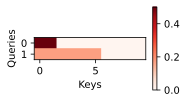

In [7]:
# 注意力权重
# 调用d2l.show_heatmaps函数，显示注意力权重的热图
d2l.show_heatmaps(attention.attention_weights.reshape((1,1,2,10)),
                 xlabel='Keys', ylabel='Queries')

In [8]:
# 缩放点积注意力
class DotProductAttention(nn.Module):
    """缩放点积注意力"""
    def __init__(self, dropout, **kwargs):
        super(DotProductAttention, self).__init__(**kwargs)
        # Dropout层，用于随机丢弃一部分注意力权重
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, queries, keys, values, valid_lens=None):
        # 获取查询向量的维度d
        d = queries.shape[-1]
        # 计算点积注意力得分，并进行缩放
        scores = torch.bmm(queries, keys.transpose(1,2)) / math.sqrt(d)
        # 使用遮蔽softmax计算注意力权重
        self.attention_weights = masked_softmax(scores, valid_lens)
        # 根据注意力权重对values进行加权求和
        return torch.bmm(self.dropout(self.attention_weights), values)

In [9]:
# 演示上述的DotProductAttention类
# 创建查询张量
queries = torch.normal(0,1,(2,1,2))
# 创建缩放点积注意力对象
attention = DotProductAttention(dropout=0.5)
# 设置为评估模式，不使用dropout
attention.eval()
# 调用缩放点积注意力对象的forward方法
attention(queries, keys, values, valid_lens)

tensor([[[ 2.0000,  3.0000,  4.0000,  5.0000]],

        [[10.0000, 11.0000, 12.0000, 13.0000]]])

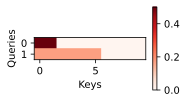

In [10]:
# 均匀的注意力权重
# 调用d2l.show_heatmaps函数，显示注意力权重的热图
d2l.show_heatmaps(attention.attention_weights.reshape((1,1,2,10)),
                 xlabel='Keys', ylabel='Queries')